In [1]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from dataclasses import dataclass

In [87]:
@dataclass
class MarketConfig:
    start_price: float = 100.0
    drift: float = 0.0
    base_vol: float = np.random.normal(0.1,0.4)
    dt: float = 0.1
    total_time: int = 1000
        
    lambda_poisson: float = 15
    order_persistence: float = 0.7
    impact_score: float = 0.1
        
    tick: float = 0.01
    spread: float = 0.2
    quote_size: int = 1
    inventory_gamma: float = 0.01
        
    toxicity_alpha: float = 0.35
    kappa: float = 3
    k: float = 8

In [3]:
class MarketPrice:
    def __init__(self, config: MarketConfig):
        self.config = config
        self.mid_price = config.start_price
        self.price_history = [self.mid_price]
        
    def StohasticsPrice(self):
        noise = np.random.normal()
        change = (self.config.drift*self.config.dt) + (self.config.base_vol*np.sqrt(self.config.dt)*noise)
        self.mid_price += change
        return self.mid_price

In [48]:
class OrderFlow:
    def __init__(self, config: MarketConfig):
        self.config = config
        self.last_side = None
        
    def PoissonGeneration(self):
        prob_arrive = 1 - np.exp(-self.config.lambda_poisson*self.config.dt)
        return np.random.rand() < prob_arrive
    
    def TraderType(self):
        return np.random.rand() < self.config.toxicity_alpha
    
    def OrderSide(self):
        if self.last_side == None:
            side = np.random.choice(['buy', 'sell'])
        else:
            if np.random.rand() < self.config.order_persistence:
                side = self.last_side
            else:
                side = 'sell' if self.last_side == 'buy' else 'buy'
        
        self.last_side = side
        return side

In [49]:
class MarketMaker:
    def __init__(self, config: MarketConfig):
        self.config = config
        self.cash = 0.0
        self.inventory = 0
        
        self.recent_trades = []
        self.inventory_history = [0]
        self.pnl_history = [0.0]
        
    def Toxicity(self):
        window = self.recent_trades[-10:]
        if len(window) < 5:
            return 0.0
        
        buys = sum(1 for side in window if side == 'buy')
        sells = sum(1 for side in window if side == 'sell')
        imbalance = abs(buys - sells) / len(window)
        
        return imbalance
        
    def Quote(self, mid_price):
        # Avellaneda-Stoikov
        skewed_mid = mid_price - (self.inventory * self.config.inventory_gamma)
        hat_alpha = self.Toxicity()
        dynamic_spread = self.config.spread * (1.0 + self.config.kappa * hat_alpha)
        
        half_spread = dynamic_spread / 2.0   
        bid = np.floor((skewed_mid - half_spread) / self.config.tick) * self.config.tick
        ask = np.ceil((skewed_mid + half_spread) / self.config.tick) * self.config.tick

        return bid, ask
    
    def ExecuteTrade(self, side, bid, ask):
        if side == 'buy':
            self.inventory -= self.config.quote_size
            self.cash += ask * self.config.quote_size
        elif side == 'sell':
            self.inventory += self.config.quote_size
            self.cash -= bid * self.config.quote_size
            
        self.recent_trades.append(side)
        self.inventory_history.append(self.inventory)
        
    def update_pnl(self, current_mid):
        total_wealth = self.cash + self.inventory * current_mid
        return total_wealth

In [89]:
class Performance:
    def __init__(self, config: MarketConfig):
        self.config = config
        
    def Metrix(self, df):

        df['Tick_Returns'] = df['PnL'].diff().fillna(0)
        
        final_pnl = df['PnL'].iloc[-1]
        final_adverse = df['Adverse_PnL'].iloc[-1]
        
        rolling_peak = df['PnL'].cummax()
        drawdowns = rolling_peak - df['PnL']
        max_drawdown = drawdowns.max()
        
        mean_tick_return = df['Tick_Returns'].mean()
        std_tick_return = df['Tick_Returns'].std()
        
        downside_ticks = df['Tick_Returns'][df['Tick_Returns'] < 0]
        std_downside_tick = downside_ticks.std() if len(downside_ticks) > 0 else 0

        path_scaling = np.sqrt(len(df))
        
        if std_tick_return > 0:
            # Session-normalized Sharpe Ratio
            stable_sharpe = (mean_tick_return / std_tick_return) * path_scaling
            # Standard high-frequency information ratio format:
            hf_info_ratio = (mean_tick_return / std_tick_return) 
        else:
            stable_sharpe = 0.0
            hf_info_ratio = 0.0
            
        if std_downside_tick > 0:
            stable_sortino = (mean_tick_return / std_downside_tick) * path_scaling
        else:
            stable_sortino = 0.0
            
        calmar = (final_pnl / max_drawdown) if max_drawdown > 0 else 0
        inventory_turns = df['Inventory'].diff().abs().sum()

        # Print the normalized dashboard
        print(f"Final Gross PnL:         ${final_pnl:,.2f}")
        print(f"Max Drawdown:   ${max_drawdown:,.2f}")
        print("-" * 50)
        print(f"Stable Sharpe:    {stable_sharpe:.4f}")
        print(f"Stable Sortino:   {stable_sortino:.4f}")
        print(f"Information Ratio: {hf_info_ratio:.6f} (Per-tick edge)")
        print(f"Calmar Ratio:             {calmar:.4f}")
        print(f"Total Inventory Turns:    {inventory_turns:.0f}")
    
    def GraphPlot(self, df):
        plt.figure(figsize=(10, 8))
        
        plt.subplot(3,1,1)
        plt.plot(df['mid_price'], alpha=0.7, color='blue', label='Mid Price')
        plt.axhline(y=100, color='green', linestyle='--', alpha=0.5, label='Start Price')
        plt.title("Market Making Mid-Price Simulation (Arithmetic)")
        plt.xlabel("Time Steps")
        plt.ylabel("Price")
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.subplot(3,1,2)
        plt.plot(df['PnL'], color='green', linewidth=2, label='Mark-to-Market PnL')
        plt.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Breakeven Baseline')
        plt.title("Market Making Strategy Performance Equity Curve", fontsize=12, fontweight='bold')
        plt.xlabel("Simulation Ticks / Time Steps")
        plt.ylabel("Total Wealth Value ($)")
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.legend(loc='upper left')
        
        plt.subplot(3,1,3)
        plt.plot(df['Inventory'], color='crimson', alpha=0.5)
        plt.title('Inventory Skew and Risk Management')
        plt.xlabel("Time Steps")
        plt.ylabel("Inventory")
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

In [70]:
class Simulator:
    def __init__(self, config: MarketConfig):
        self.config = config
        self.price_engine = MarketPrice(config=config)
        self.flow_engine = OrderFlow(config=config)
        self.mm_engine = MarketMaker(config=config)
        self.perfor_engine = Performance(config=config)
        
        self.start_time = 0
        self.adverse_pnl = 0.0
        self.data_log = []
        
    def run(self):
        while self.start_time < self.config.total_time:
            old_mid = self.price_engine.mid_price
            mid_price = self.price_engine.StohasticsPrice()
            price_delta = mid_price - old_mid
            
            bid, ask = self.mm_engine.Quote(mid_price)
            side = 'NONE'
            event_tag = 'NONE'
            
            if self.flow_engine.PoissonGeneration():
                is_informed = self.flow_engine.TraderType()

                if is_informed:
                    side = 'buy' if price_delta > 0 else 'sell'
                    actual_impact = self.config.impact_score*3
                    event_tag = "TOXIC"
                else:
                    side = self.flow_engine.OrderSide()
                    actual_impact = self.config.impact_score*1
                    event_tag = "NOISE"
                    
                if side == 'buy':
                    delta = ask - mid_price
                else:
                    delta = mid_price - bid                    
                fill_prob = np.exp(-self.config.k * delta)
                
                if np.random.rand() < fill_prob:
                    self.mm_engine.ExecuteTrade(side, bid, ask)

                    impact_dir = 1 if side == 'buy' else -1
                    self.price_engine.mid_price += impact_dir * actual_impact

                    current_mid = self.price_engine.mid_price
                    
                    if is_informed:
                        if side == 'buy':
                            self.adverse_pnl -= price_delta
                        else:
                            self.adverse_pnl += price_delta
                else:
                    pass
            else:
                pass
            
            snapshot_dict = {
                'snapshot': self.start_time,
                'mid_price': mid_price,
                'bid': bid,
                'ask': ask,
                'PnL': self.mm_engine.update_pnl(mid_price),
                'Inventory': self.mm_engine.inventory,
                'Side': side.upper(),
                'Tag': event_tag,
                'Adverse_PnL': self.adverse_pnl
                  
            }
            
            self.data_log.append(snapshot_dict)
            self.start_time += self.config.dt

        data_log_df = pd.DataFrame(self.data_log)
        return data_log_df

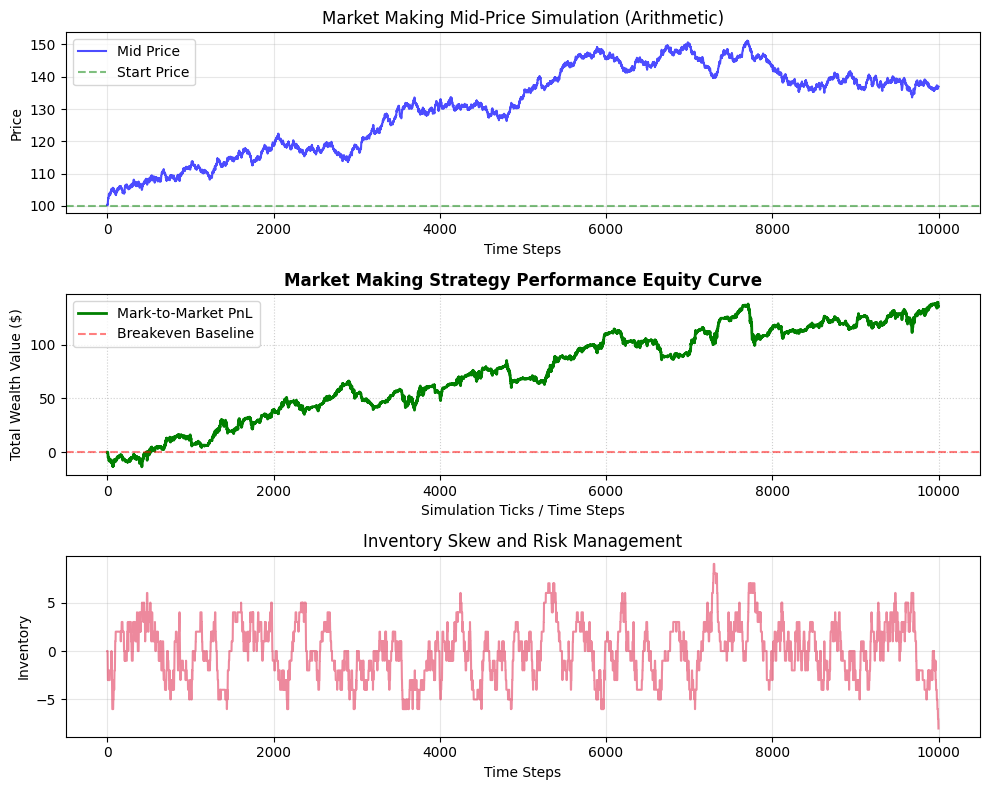

Final Gross PnL:         $135.64
Max Drawdown:   $38.33
--------------------------------------------------
Stable Sharpe:    2.2488
Stable Sortino:   2.8184
Information Ratio: 0.022488 (Per-tick edge)
Calmar Ratio:             3.5391
Total Inventory Turns:    1768


In [90]:
def run_sim():
    config = MarketConfig()
    sim = Simulator(config=config)
    result = Performance(config=config)
    
    data_log = sim.run()
    result.GraphPlot(data_log)
    result.Metrix(data_log)
    
run_sim()